In [138]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

Select and display the job_title and job_location columns for the first 5 rows of the DataFrame using the iloc method.

In [ ]:
df.iloc[0:5, 1:3]

,job_title,job_location
0,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT"
1,Data Analyst,"Guadalajara, Jalisco, Mexico"
2,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany"
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX"
4,Data Engineer- Sr Jobs,"Washington, DC"


Retrieve the columns starting with job_title all the way to job_posted_date for rows with an index of 5 to 9. Use the loc method.

In [ ]:
df.loc[5:9, 'job_title':'job_posted_date']

,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date
5,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59
6,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18
7,Data Engineer,Anywhere,via LinkedIn,Full-time,True,Romania,2023-12-07 13:40:49
8,Technology & Operations Business Analyst,"Copenhagen, Denmark",via Trabajo.org,Full-time,False,Denmark,2023-06-05 13:44:34
9,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57


Retrieve the job_title and salary_year_avg for the first 15 rows where the job_country is 'United States'. Use the iloc method.

In [ ]:
df_us = df[df['job_country']== 'United States']
df_us.iloc[:15, [1, 12]]
df_us[['job_title', 'salary_year_avg']].iloc[:15]

,job_title,salary_year_avg
0,Senior Clinical Data Engineer / Principal Clin...,NaN
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,NaN
5,GCP Data Engineer,NaN
6,Senior Data Engineer - GCP Cloud,NaN
9,Data Scientist II,NaN
11,Data Engineer,NaN
13,Senior Data Engineer,NaN
17,Data Science Team Lead,NaN
26,Data Engineer,NaN
27,"Principal Data Engineer (Lead), Knowledge Grap...",NaN


Select and display the job_title, job_location, and job_posted_date columns for rows where the job_posted_date is after '2023-05-01' using the loc method.

In [ ]:
df_updated = df[df['job_posted_date']>'2023-05-01']
df_updated[['job_title', 'job_location', 'job_posted_date']]
df_updated.loc[:, ['job_title', 'job_location', 'job_posted_date']]
df.loc[df['job_posted_date'] > '2023-05-01', ['job_title', 'job_location', 'job_posted_date']]

,job_title,job_location,job_posted_date
0,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",2023-06-16 13:44:15
2,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",2023-10-10 13:14:55
3,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",2023-07-04 13:01:41
4,Data Engineer- Sr Jobs,"Washington, DC",2023-08-07 14:29:36
5,GCP Data Engineer,Anywhere,2023-11-07 14:01:59
...,...,...,...
785694,Data Engineer,"Graz, Austria",2023-05-07 07:07:37
785696,Senior Analytics Engineer,"Colombia, Huila, Colombia",2023-10-23 06:31:25
785698,"Data Engineer, Gerencia Business Intelligence","Las Condes, Chile",2023-08-09 06:32:00
785701,"Data Engineer, Gerencia Business Intelligence","Santiago, Chile",2023-08-09 06:31:57


Remove rows where the salary_year_avg column has missing values. Display the number of rows before and after removing.

In [ ]:
df_removed = df.dropna(subset='salary_year_avg')

print('Before: ', len(df))
print('After:  ', len(df_removed))
print('Delta:  ', len(df)-len(df_removed))

Before:  785741
After:   22003
Delta:   763738


Remove duplicate rows from the DataFrame based on the job_location column. Display the number of rows before and after removing duplicates.

In [ ]:
df_cleaned = df.drop_duplicates(subset='job_location')

print('Before: ', len(df))
print('After:  ', len(df_cleaned))
print('Delta:  ', len(df)-len(df_cleaned))

len(df), len(df_cleaned)

Before:  785741
After:   17218
Delta:   768523


(785741, 17218)

Fill missing values in the salary_rate column with the string 'Unknown'. Display the first 10 rows of the salary_rate column before and after filling.

In [ ]:
salary_rate_before = df['salary_rate'].head(10)
salary_rate_filed = df['salary_rate'].fillna('Unknown')
salary_rate_after = df_filed.head(10)
salary_rate_before, salary_rate_after


(0    NaN
 1    NaN
 2    NaN
 3    NaN
 4    NaN
 5    NaN
 6    NaN
 7    NaN
 8    NaN
 9    NaN
 Name: salary_rate, dtype: str,
 0    Unknown
 1    Unknown
 2    Unknown
 3    Unknown
 4    Unknown
 5    Unknown
 6    Unknown
 7    Unknown
 8    Unknown
 9    Unknown
 Name: salary_rate, dtype: str)

Create a copy of the DataFrame and drop rows where the salary_year_avg column has missing values. Display the first 5 rows of the cleaned DataFrame.

In [ ]:
df_copy = df.copy()
df_copy = df_copy.dropna(subset='salary_year_avg')
df_copy.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
28,Data Scientist,CRM Data Specialist,"San José Province, San José, Costa Rica",via Ai-Jobs.net,Full-time,False,Costa Rica,2023-08-01 13:37:57,False,False,Costa Rica,year,109500.0,NaN,Netskope,"['gdpr', 'excel']","{'analyst_tools': ['excel'], 'libraries': ['gd..."
77,Data Engineer,Data Engineer,"Arlington, VA",via LinkedIn,Full-time,False,Sudan,2023-06-26 14:22:54,False,False,Sudan,year,140000.0,NaN,Intelletec,"['mongodb', 'mongodb', 'python', 'r', 'sql', '...","{'analyst_tools': ['tableau'], 'cloud': ['orac..."
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,NaN,Apex Systems,"['sql', 'python']","{'programming': ['sql', 'python']}"
100,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,"California, United States",2023-07-31 13:01:18,False,True,United States,year,228222.0,NaN,TikTok,"['sql', 'r', 'python', 'express']","{'programming': ['sql', 'r', 'python'], 'webfr..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,"['python', 'r', 'alteryx', 'tableau']","{'analyst_tools': ['alteryx', 'tableau'], 'pro..."


Create a new DataFrame that is a random sample of 10% of the original DataFrame. Display the first 5 rows of the sampled DataFrame.

In [ ]:
df_sample = df.sample(frac=0.1)
df_sample.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
666431,Data Engineer,Data Centre Facilities Management Engineer (Pe...,Singapore,via LinkedIn,Full-time,False,Singapore,2023-08-22 10:21:29,False,False,Singapore,NaN,NaN,NaN,Page Personnel,NaN,NaN
351921,Data Analyst,"Data Analyst, Travel Services","Glendale, CA",via BeBee,Full-time,False,"California, United States",2023-12-08 23:00:57,True,False,United States,NaN,NaN,NaN,Taleo BE,['c'],{'programming': ['c']}
752592,Data Analyst,Assistant B2B Data Analytics Manager,"İstanbul, Türkiye",via Indeed,Full-time,False,Turkey,2023-04-21 20:44:53,False,False,Turkey,NaN,NaN,NaN,Unilever,"['sas', 'sas', 'excel', 'tableau']","{'analyst_tools': ['sas', 'excel', 'tableau'],..."
636418,Business Analyst,Analyst,"Copenhagen, Denmark",via LinkedIn,Full-time,False,Denmark,2023-12-11 13:01:39,False,False,Denmark,NaN,NaN,NaN,TNL Accounting Services,['excel'],{'analyst_tools': ['excel']}
390436,Machine Learning Engineer,Senior Machine Learning Engineer,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-07-19 18:12:10,False,False,India,year,166000.0,NaN,Toast,"['python', 'shell', 'dynamodb', 'aws', 'scikit...","{'cloud': ['aws'], 'databases': ['dynamodb'], ..."


Create a copy of the original DataFrame and fill in missing values in the salary_year_avg column with the median salary. Display the first 5 rows of the altered DataFrame.

In [ ]:
df_copy = df.copy()
median_salary = df['salary_year_avg'].median()
df_copy['salary_year_avg'] = df_copy['salary_year_avg'].fillna(value=median_salary)
df_copy['salary_year_avg'].head()

0    115000.0
1    115000.0
2    115000.0
3    115000.0
4    115000.0
Name: salary_year_avg, dtype: float64

Create a pivot table to count the number of job postings for each job_title_short and job_country. Display the first 10 rows of the resulting pivot table.

In [ ]:
df.pivot_table(index=['job_title_short', 'job_country'], aggfunc='size').head(10)

job_title_short   job_country
Business Analyst  Afghanistan      4
                  Albania         11
                  Algeria         21
                  Angola           1
                  Argentina      453
                  Armenia         29
                  Australia      928
                  Austria        738
                  Azerbaijan      16
                  Bahamas          5
dtype: int64

Create a pivot table to find the maximum, minimum, and average salary_year_avg for each company_name. Display the first 5 rows of the resulting pivot table.

In [ ]:
df.pivot_table(values='salary_year_avg', index='company_name', aggfunc=['max', 'min', 'mean']).head()

,max,min,mean
,salary_year_avg,salary_year_avg,salary_year_avg
company_name,,,
#twiceasnice Recruiting,120000.000000,61000.000000,77750.000000
/dev/color,125000.000000,125000.000000,125000.000000
0nward Select,92500.000000,92500.000000,92500.000000
1 Point System,137290.484375,137290.484375,137290.484375
1 Point System LLC.,170000.000000,170000.000000,170000.000000


Create a pivot table to calculate the median of salary_year_avg for each company_name and job_country:

    - Filter the pivot table to only include 'Data Scientist' roles.
    - Then filter the pivot table to only include company_name with a median salary_year_avg greater than 200,000.
    - Display the first 10 rows of the resulting pivot table.

In [ ]:
df_science = df[df['job_title_short']=='Data Scientist']
df_pivot = df_science.pivot_table(values='salary_year_avg', index=['company_name','job_country'], aggfunc='median', )
df_pivot[df_pivot['salary_year_avg']>200_000].head(10)

salary_year_avg
company_name        job_country                   
ACT                 Sudan                 225000.0
                    United States         225000.0
Abbott              United States         204000.0
Airbnb              United States         212500.0
Airtable            Sudan                 215500.0
                    United States         233500.0
Algo Capital Group  Sudan                 325000.0
                    United States         350000.0
Amadeus Search      United States         232500.0
Analog Devices, Inc United States         375000.0

Set the job_posted_date column as the index of the DataFrame and display the first 5 rows.

In [ ]:
df.set_index('job_posted_date').head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
job_posted_date,,,,,,,,,,,,,,,,
2023-06-16 13:44:15,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
2023-01-14 13:18:07,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2023-10-10 13:14:55,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
2023-07-04 13:01:41,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
2023-08-07 14:29:36,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


Reset the index of the DataFrame from the last problem (where job_posted_date column is the index) to the default integer index and drop the existing index. Display the first 5 rows.

In [ ]:
df.reset_index(drop=True, inplace=True)
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


Create a pivot table to calculate the median salary_year_avg for each company_name and sort the index in descending order. Display the first 5 rows.

In [ ]:
df_pivot = df.pivot_table(values='salary_year_avg', index='company_name', aggfunc='median').sort_values(by='company_name' ,ascending=False)
df_pivot.head()

,salary_year_avg
company_name,
​Illinois State Board of Education,62536.0
Технологическая компания,280000.0
ЛАНИТ,400000.0
ztp,95000.0
zooplus SE,161750.0


Create a pivot table to calculate the median salary_year_avg for each job_title_short, reset the index of the resulting pivot table, then set the index to salary_year_avg. Display the first 5 rows.

In [ ]:
df_pivot = df.pivot_table(values='salary_year_avg', index='job_title_short', aggfunc='median')
df_pivot.reset_index(inplace=True)
df_pivot.set_index('salary_year_avg', inplace=True)
df_pivot.head()

,job_title_short
salary_year_avg,
85000.0,Business Analyst
90000.0,Cloud Engineer
90000.0,Data Analyst
125000.0,Data Engineer
127500.0,Data Scientist


Create a DataFrame df_us_jobs that contains only job postings in the United States.
Then, create another DataFrame df_monthly_postings that counts the number of U.S. job postings for each month.
Merge these two DataFrames on the job_posted_month column using a right join, and display the first 5 rows of the resulting DataFrame.

In [ ]:
df_us_jobs = df[df['job_country'] == 'United States'].copy()
df_us_jobs['job_posted_month'] = df_us_jobs['job_posted_date'].dt.to_period('M') 
df_monthly_postings = df_us_jobs.groupby('job_posted_month').size().reset_index(name='postings_count')
df_merged = pd.merge(df_us_jobs, df_monthly_postings, on='job_posted_month', how='right')
df_merged.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month,postings_count
0,Data Engineer,Data Engineer,"Fort Worth, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-25 13:24:01,False,False,United States,NaN,NaN,NaN,Programmers.io,"['sql', 'python']","{'programming': ['sql', 'python']}",2023-01,22670
1,Data Engineer,Data Engineer,"San Mateo, CA",via LinkedIn,Full-time,False,"California, United States",2023-01-28 13:07:30,False,True,United States,NaN,NaN,NaN,Verkada,"['sql', 'python', 'aws', 'looker']","{'analyst_tools': ['looker'], 'cloud': ['aws']...",2023-01,22670
2,Business Analyst,Business Intelligence Intern,"Dallas, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-04 13:02:07,False,False,United States,NaN,NaN,NaN,Copart,"['r', 'python', 'sql', 'tableau', 'power bi']","{'analyst_tools': ['tableau', 'power bi'], 'pr...",2023-01,22670
3,Data Engineer,Data Engineer,"Cincinnati, OH",via SimplyHired,Full-time,False,"Texas, United States",2023-01-22 13:08:53,False,False,United States,NaN,NaN,NaN,Divisions Maintenance Group,"['sql', 'nosql', 'python', 'java', 'c++', 'sca...","{'databases': ['cassandra'], 'libraries': ['ha...",2023-01,22670
4,Data Analyst,Data Analyst,"Tampa, FL",via LinkedIn,Full-time,False,"Florida, United States",2023-01-19 13:19:45,False,False,United States,NaN,NaN,NaN,Citi,"['sql', 'python', 'unix', 'excel', 'jira']","{'analyst_tools': ['excel'], 'async': ['jira']...",2023-01,22670


Create a DataFrame df_not_remote_jobs that contains only job postings that do not offer remote work (job_work_from_home == False).

From df_not_remote_jobs, calculate the average yearly salary (salary_year_avg) for each job title (job_title_short).
Store the result in a new DataFrame df_not_remote_salary.
Rename the salary column to salary_not_remote_avg.

Merge df_not_remote_jobs and df_not_remote_salary on the job_title_short column using a right join.

Display the first 5 rows of the resulting DataFrame.

In [ ]:
df_not_remote_jobs = df[df['job_work_from_home'] == False]
df_not_remote_salary = df_not_remote_jobs.groupby('job_title_short')['salary_year_avg'].mean().reset_index(name='salary_not_remote_avg')
pd.merge(df_not_remote_jobs, df_not_remote_salary, on='job_title_short', how='right').head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month,salary_not_remote_avg
0,Business Analyst,Technology & Operations Business Analyst,"Copenhagen, Denmark",via Trabajo.org,Full-time,False,Denmark,2023-06-05 13:44:34,False,False,Denmark,NaN,NaN,NaN,Hempel,"['excel', 'powerpoint', 'power bi']","{'analyst_tools': ['excel', 'powerpoint', 'pow...",2023-06,90177.41994
1,Business Analyst,Business Intelligence Intern,"Dallas, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-04 13:02:07,False,False,United States,NaN,NaN,NaN,Copart,"['r', 'python', 'sql', 'tableau', 'power bi']","{'analyst_tools': ['tableau', 'power bi'], 'pr...",2023-01,90177.41994
2,Business Analyst,BI Engineer,Namibia,via Intellijobs.ai,Full-time,False,Namibia,2023-03-05 14:10:49,False,False,Namibia,NaN,NaN,NaN,Innover,"['sql', 'gcp', 'looker', 'tableau']","{'analyst_tools': ['looker', 'tableau'], 'clou...",2023-03,90177.41994
3,Business Analyst,Business Analyst,"Tel Aviv-Yafo, Israel",via Comeet,Full-time,False,Israel,2023-09-05 13:50:12,False,False,Israel,NaN,NaN,NaN,ironSource,"['sql', 'excel']","{'analyst_tools': ['excel'], 'programming': ['...",2023-09,90177.41994
4,Business Analyst,Commercial Analyst,South Africa,via LinkedIn,Full-time,False,South Africa,2023-02-14 13:36:23,True,False,South Africa,NaN,NaN,NaN,PEP,"['sql', 'tableau', 'spss', 'sap']","{'analyst_tools': ['tableau', 'spss', 'sap'], ...",2023-02,90177.41994


Create a DataFrame df_company_salary that calculates the average yearly salary for each company.
Then, create another DataFrame df_company_remote that counts the number of remote job postings for each company. Name this count column remote_count.
Merge these two DataFrames on the company_name column using an inner join and display the first 5 rows of the resulting DataFrame.

In [ ]:
df_company_salary = df.groupby('company_name')['salary_year_avg'].mean().reset_index()
df_company_remote = (df[df['job_work_from_home'] == True]
                    .groupby('company_name')
                    .size()
                    .reset_index(name='remote_count')
                    )
pd.merge(df_company_salary, df_company_remote, on='company_name').head()


,company_name,salary_year_avg,remote_count
0,#EqualsTrue,NaN,4
1,#TeamGoHealth,NaN,1
2,#twiceasnice Recruiting,77750.0,1
3,&Work,NaN,1
4,"(AEG) Application Engineering Group, Inc.",NaN,1


Concatenate two DataFrames to analyze job postings for Data Scientists and Data Analysts:

Create one DataFrame with job postings for Data Scientists named data_scientist_df and another for Data Analysts named data_analyst_df.
Concatenate them and display the combined DataFrame called combined_df.

In [ ]:
data_scientist_df = df[df['job_title_short'] == 'Data Scientist']
data_analyst_df = df[df['job_title_short'] == 'Data Analyst']
pd.concat([data_scientist_df, data_analyst_df], ignore_index=True).head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
0,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'...",2023-04
1,Data Scientist,Data Science Team Lead,"Laurel, MD",via APL Careers - Johns Hopkins University App...,Full-time,False,Georgia,2023-06-13 13:25:17,False,True,United States,NaN,NaN,NaN,Johns Hopkins Applied Physics Laboratory,"['go', 'apl', 'excel']","{'analyst_tools': ['excel'], 'programming': ['...",2023-06
2,Data Scientist,Data Scientist,"Pune, Maharashtra, India",via Indeed,Full-time,False,India,2023-04-26 13:20:12,False,False,India,NaN,NaN,NaN,Bitwise Solutions,"['r', 'sql', 'python', 'scala', 'java', 'c++',...","{'analyst_tools': ['tableau'], 'libraries': ['...",2023-04
3,Data Scientist,Data Scientist,"Zaventem, Belgium",via BeBee Belgique,Full-time,False,Belgium,2023-01-31 13:53:38,False,False,Belgium,NaN,NaN,NaN,Devoteam,"['r', 'python', 'sql', 'pandas', 'numpy', 'sci...","{'libraries': ['pandas', 'numpy', 'scikit-lear...",2023-01
4,Data Scientist,Stage - data scientist – génération ia de donn...,"Asnières-sur-Seine, France",via Jobijoba,Full-time,False,France,2023-02-23 13:41:21,False,False,France,NaN,NaN,NaN,Credit Agricole,NaN,NaN,2023-02


Concatenate DataFrames to analyze job postings by month:

Create DataFrames for job postings for the last quarter (October, November, and December). These are respectively called oct_df, nov_df, and dec_df.
Concatenate them and display the combined DataFrame named combined_df.

In [ ]:
oct_df = df[df['job_posted_date'].dt.month == 10]
nov_df = df[df['job_posted_date'].dt.month == 11]
dec_df = df[df['job_posted_date'].dt.month == 12]

pd.concat([oct_df, nov_df, dec_df], ignore_index=True).head()


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
0,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],...",2023-10
1,Data Engineer,Data Engineer,"Aberdeen, UK",via LinkedIn,Temp work,False,United Kingdom,2023-10-19 13:37:16,False,False,United Kingdom,NaN,NaN,NaN,Orion Group,"['python', 'sql', 'power bi']","{'analyst_tools': ['power bi'], 'programming':...",2023-10
2,Data Analyst,Data Analyst,"Warsaw, Poland",via Praca Trabajo.org,Full-time,False,Poland,2023-10-16 13:36:54,False,False,Poland,NaN,NaN,NaN,Glovo,"['sql', 'python', 'r', 'redshift', 'pandas', '...","{'analyst_tools': ['excel', 'looker', 'tableau...",2023-10
3,Data Analyst,Stage - Data Analyst F/H,"Paris, France",via LinkedIn,Full-time and Internship,False,France,2023-10-19 13:59:31,False,False,France,NaN,NaN,NaN,GROUPE BON MARCHÉ : Le Bon Marché Rive Gauche ...,['sql'],{'programming': ['sql']},2023-10
4,Data Analyst,"Data Analyst (Bangkok Based, relocation provided)","Rome, Metropolitan City of Rome Capital, Italy",via LinkedIn,Full-time,False,Italy,2023-10-30 13:13:21,False,False,Italy,NaN,NaN,NaN,Agoda,"['sas', 'sas', 'r', 'python', 'vba', 'sql', 'j...","{'analyst_tools': ['sas', 'spss', 'tableau', '...",2023-10


Concatenate DataFrames to analyze job postings for different job types:

Create DataFrames for 'Full-time' roles (called full_time_df) and 'Part-time' roles (called part_time_df) job postings.
Concatenate them and display the combined DataFrame named combined_df.

In [ ]:
full_time_df = df[df['job_schedule_type'] == 'Full-time']
part_time_df = df[df['job_schedule_type'] == 'Part-time']

combined_df = pd.concat([full_time_df, part_time_df], ignore_index=True)
combined_df.head()


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN,2023-06
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr...",2023-01
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],...",2023-10
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",2023-07
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl...",2023-08


Export the DataFrame to a CSV file named data_jobs_export.csv without including the index. Inspect the contents of the CSV exported.

In [ ]:
df.to_csv('data_jobs_export.csv', index=False)

Filter the DataFrame to include only job postings with 'Data Scientist' in the job_title_short column.
Export the filtered DataFrame to a CSV file named data_scientist_jobs.csv without including the index.
Inspect that the CSV has been exported with the correct filtered data.

In [ ]:
filtered_df = df[df['job_title_short'] == 'Data Scientist']
filtered_df.to_csv('data_scientist_jobs.csv', index=False)

Filter the DataFrame to include only job postings with 'New York, NY' in the job_location column.
Export the filtered DataFrame to an Excel file named new_york_jobs.xlsx without including the index.
Display the first 5 rows of the filtered DataFrame to confirm the export.

In [ ]:
df_filtered = df[df['job_location'] == 'New York, NY']
df_filtered.to_excel('new_york_jobs.xlsx', index=False)

Convert the job_posted_date column to a string format 'YYYY-MM-DD' and create a new column job_posted_date_str.

In [ ]:
df['job_posted_date_str'] = df['job_posted_date'].apply(lambda x: x.strftime('%Y-%m-%d'))
df[['job_posted_date', 'job_posted_date_str']].head()

,job_posted_date,job_posted_date_str
0,2023-06-16 13:44:15,2023-06-16
1,2023-01-14 13:18:07,2023-01-14
2,2023-10-10 13:14:55,2023-10-10
3,2023-07-04 13:01:41,2023-07-04
4,2023-08-07 14:29:36,2023-08-07


Calculate the number of days since each job was posted. Create a new column days_since_posted that contains this value. Use the job_posted_date column.

Note: You need to import the datetime library and use the datetime module to get the current date using .now().

In [ ]:
from datetime import datetime

df['days_since_posted'] = df['job_posted_date'].apply(lambda x: (datetime.now() - x).days )
df[['job_posted_date', 'days_since_posted']].head()

,job_posted_date,days_since_posted
0,2023-06-16 13:44:15,1011
1,2023-01-14 13:18:07,1164
2,2023-10-10 13:14:55,895
3,2023-07-04 13:01:41,993
4,2023-08-07 14:29:36,959


Create a copy of the DataFrame called df_filtered and drop the NaN values for salary_year_avg.
Then, create a new column salary_category that categorizes the salary_year_avg into three categories: 'Low' for salaries less than 60,000, 'Medium' for salaries between 60,000 and 100,000, and 'High' for salaries greater than 100,000.
Then show the df_filtered DataFrame and the salary_year_avg and salary_category columns.

In [ ]:
df_filtered = df.dropna(subset='salary_year_avg').copy()

def categories(salary):
    if salary < 60_000:
        return 'Low'
    if salary > 100_000:
        return 'High'
    else:
        return 'Medium'

df_filtered['salary_category'] = df_filtered['salary_year_avg'].apply(categories)
df_filtered[['salary_year_avg', 'salary_category']].head()

,salary_year_avg,salary_category
28,109500.0,High
77,140000.0,High
92,120000.0,High
100,228222.0,High
109,89000.0,Medium


Using the ast library, clean up the job_skills column to be of the list data type in preparation for exploding this column.
NOTE: For future problems, it'll be assumed that you have done this step in preparation for exploding this column.
Explode the job_skills column in the DataFrame and create a bar plot using pandas of the top 10 most common skills for Cloud Engineer.
Add labels for the x-axis (label as 'Skills'), y-axis (label as 'Count') and a title (set as 'Top 10 Most Common Skills for Cloud Engineers') for the plot.

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'python'),
  Text(1, 0, 'aws'),
  Text(2, 0, 'azure'),
  Text(3, 0, 'sql'),
  Text(4, 0, 'linux'),
  Text(5, 0, 'terraform'),
  Text(6, 0, 'kubernetes'),
  Text(7, 0, 'java'),
  Text(8, 0, 'gcp'),
  Text(9, 0, 'docker')])

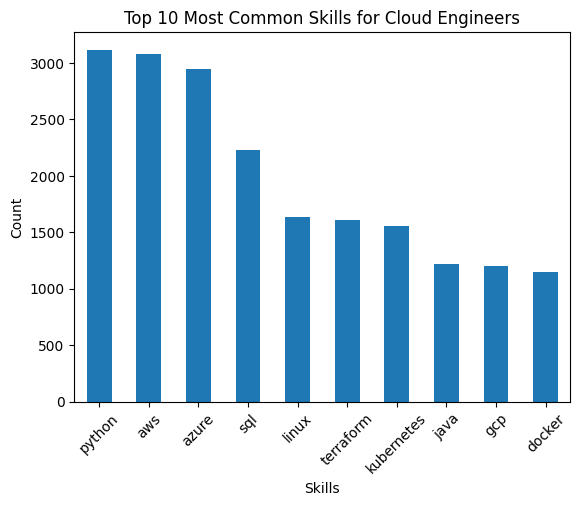

In [ ]:
df_CE = df[df['job_title_short'] == 'Cloud Engineer']
df_CE_exploded = df_CE.explode('job_skills')
skill_counts = df_CE_exploded['job_skills'].value_counts().head(10)
skill_counts.plot(kind='bar')
plt.xlabel('Skills')
plt.ylabel('Count')
plt.title('Top 10 Most Common Skills for Cloud Engineers')
plt.xticks(rotation=45)

Explode the job_skills column in the DataFrame and calculate the average salary for each skill. Display the top 5 skills with the highest average salary.

In [ ]:
df_exploded = df.explode('job_skills')
(df_exploded
.groupby('job_skills')['salary_year_avg']
.mean()
.reset_index()
.sort_values('salary_year_avg', ascending=False).head()
)

,job_skills,salary_year_avg
46,debian,196500.000000
177,ringcentral,182500.000000
114,lua,170500.000000
126,mongo,169526.929749
54,dplyr,160667.210526


Calculate the number of unique skills required for each job_title_short.

Explode the job_skills column

Group by job_title_short

Count unique skills per title (i.e., num_unique_skills)

Rename the result column to num_unique_skills and show the first 5 rows

In [ ]:
df_unique_skills = df_exploded.groupby('job_title_short')['job_skills'].unique().reset_index()
df_unique_exploded = df_unique_skills.explode('job_skills')
df_unique_exploded.groupby('job_title_short').size().reset_index(name='num_unique_skills').head()

,job_title_short,num_unique_skills
0,Business Analyst,224
1,Cloud Engineer,214
2,Data Analyst,236
3,Data Engineer,240
4,Data Scientist,238


Create a subplot with 2 rows and 1 column:

In the first subplot, plot a bar chart of the top 3 job locations by the number of job postings.
In the second subplot, plot a horizontal bar chart of the top 3 job titles by the number of job postings.
Use tight_layout() to adjust the spacing between subplots.

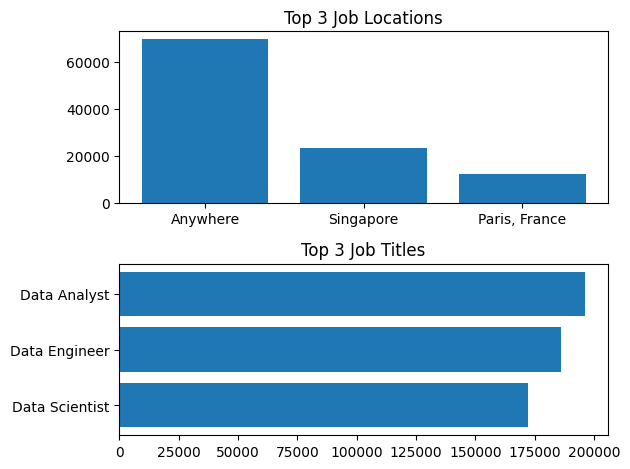

In [ ]:
fig, ax = plt.subplots(2, 1)

job_location = df['job_location'].value_counts().head(3)
ax[0].bar(job_location.index, job_location.values)
ax[0].set_title('Top 3 Job Locations')

job_title = df['job_title_short'].value_counts().head(3)
ax[1].barh(job_title.index, job_title.values)
ax[1].set_title('Top 3 Job Titles')
ax[1].invert_yaxis()

fig.tight_layout()
plt.show()

Create a subplot with 2 rows and 2 columns:

In each subplot, plot a bar chart of the top 3 job titles by the number of job postings for each job schedule type (Full-time, Part-time, Contractor, and Internship).
Use fig.tight_layout() to adjust the spacing between subplots.

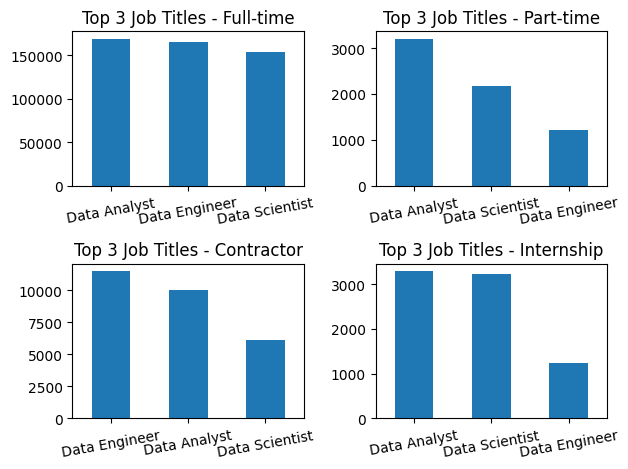

In [ ]:
schedules = ['Full-time', 'Part-time', 'Contractor', 'Internship']

fig, ax = plt.subplots(2, 2)
ax = ax.flatten()

for i, schedule in enumerate(schedules):
    df_schedule = df[df['job_schedule_type']== schedule]
    top_job_titles = df_schedule['job_title_short'].value_counts().head(3).plot(kind='bar', ax=ax[i])
    ax[i].set_title(f"Top 3 Job Titles - {schedule}")
    ax[i].tick_params(axis = 'x', rotation=10)
    ax[i].set_xlabel('')


fig.tight_layout()
plt.show()

Create a subplot with 3 rows and 1 column:

In each subplot, plot a horizontal bar chart of the top 3 job skills by the number of job postings for each job title (Senior Data Scientist, Senior Data Engineer, and Senior Data Analyst).
Use fig.tight_layout() to adjust the spacing between subplots and invert_yaxis() to invert the y-axis in each subplot.

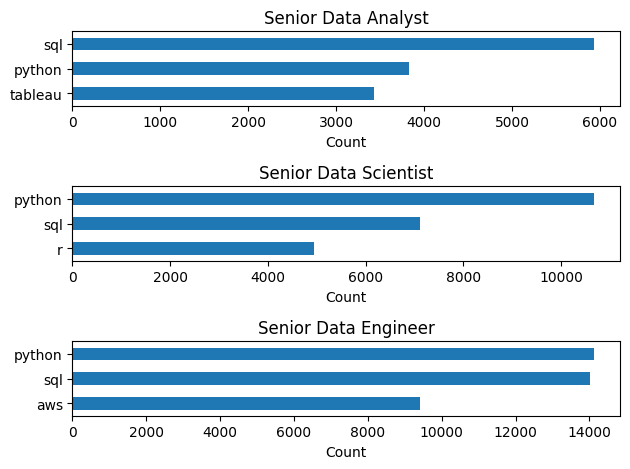

In [ ]:
job_roles = ['Senior Data Analyst', 'Senior Data Scientist', 'Senior Data Engineer']

fig, ax = plt.subplots(3, 1)

for i, job in enumerate(job_roles):
    df_skills = df[df['job_title'] == job]
    df_skills = df_skills.explode('job_skills')
    job_skills = df_skills['job_skills'].value_counts().head(3).plot(kind='barh', ax=ax[i])
    ax[i].set_title(job)
    ax[i].tick_params(axis = 'x', rotation=0)
    ax[i].invert_yaxis()
    ax[i].set_xlabel('Count')
    ax[i].set_ylabel('')

fig.tight_layout()

Create a subplot with 2 rows and 2 columns.

In each subplot, plot a horizontal bar chart of the top 5 most common job locations for each job title:

Data Analyst

Data Scientist

Data Engineer

Machine Learning Engineer

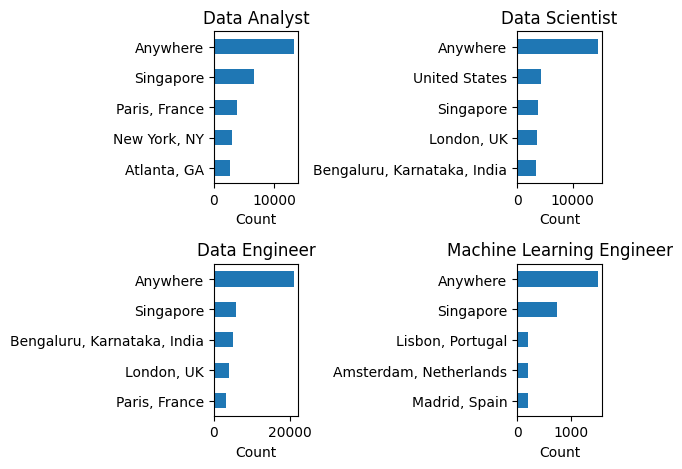

In [ ]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer', 'Machine Learning Engineer']

fig, ax = plt.subplots(2, 2)
ax = ax.flatten()

for i, job in enumerate(job_titles):
    df_job = df[df['job_title_short'] == job]
    df_job['job_location'].value_counts().head().plot(kind='barh', ax=ax[i])
    ax[i].invert_yaxis()
    ax[i].set_title(job)
    ax[i].set_xlabel('Count')
    ax[i].set_ylabel('')

fig.tight_layout()


Create a pie chart to show the proportion of job postings that mention health insurance for Data Analyst roles only:

Create a new DataFrame called df_DA that only gets Data Analyst roles.
Then count the number of data analyst roles that mention or not mention health insurance by using the job_health_insurance column.
Plot this using plt.pie(), setting labels parameter to ['No', 'Yes'], startangle to 90, and format values to display similarly to 23.1%.
Set the title to 'Proportion of Data Analyst Jobs Mentioning Health Insurance'.

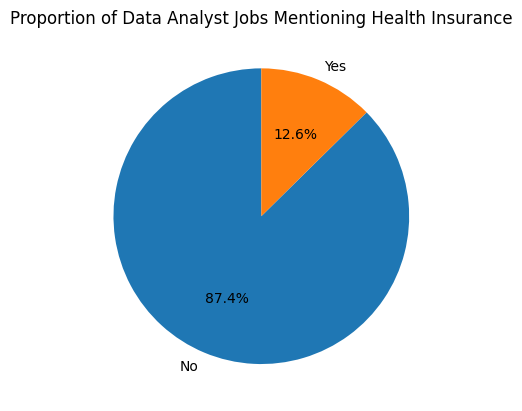

In [ ]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()
health_insurance_counts = df_DA['job_health_insurance'].value_counts()
plt.pie(health_insurance_counts, labels=['No', 'Yes'], autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Data Analyst Jobs Mentioning Health Insurance')
plt.show()


Create a pie chart showing the count of job postings per job schedule types (for only jobs that are either 'Full-time' and 'Part-time') in the DataFrame.
Create a DataFrame to filter out these job_schedule_type called df_ft_pt.
Plot this using plt.pie(), setting labels parameter to the index, startangle to 90, and format values to display similarly to 23.1%.
Add a title 'Job Schedule Full-time vs. Part-time'.

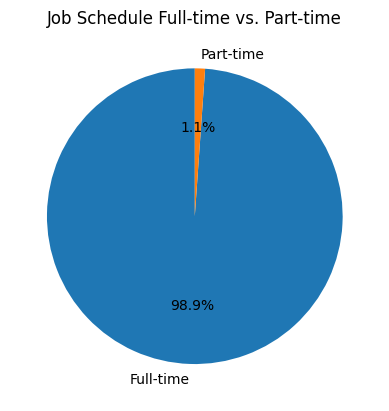

In [ ]:
df_ft_pt = df[(df['job_schedule_type'] == 'Full-time') | (df['job_schedule_type'] == 'Part-time')]
job_types = df_ft_pt['job_schedule_type'].value_counts()
plt.pie(job_types, labels=['Full-time', 'Part-time'], startangle=90, autopct='%1.1f%%')
plt.title('Job Schedule Full-time vs. Part-time')
plt.show()

Create a pie chart to show the distribution of job postings that mention a degree in the job posting versus those that do not.
Only get job postings located in the US, create a new DataFrame with this filtered data called df_US.
Use the job_no_degree_mention column for this purpose.
Customize the pie chart by exploding the slice for jobs that do not mention a degree. (Use the explode parameter set to (0, 0.1) inside of plt.pie())
Set the chart title as 'Distribution of Jobs Mentioning Degrees for US Job Postings'.

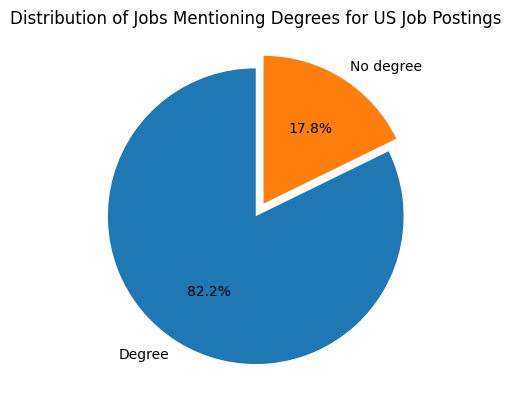

In [ ]:
df_US = df[df['job_country'] == 'United States']
degree_mentions = df_US['job_no_degree_mention'].value_counts()
plt.pie(degree_mentions, startangle=90, labels=['Degree', 'No degree'], explode=(0, 0.1), autopct='%1.1f%%')
plt.title('Distribution of Jobs Mentioning Degrees for US Job Postings')
plt.show()

Create a scatter plot to compare the median yearly salary and the number of jobs based on the job_title_short column.
To create the scatter plot first create a new DataFrame using the groupby() method to aggregate and find the median salary and job count for each job title.
Annotate each point with the job title name.

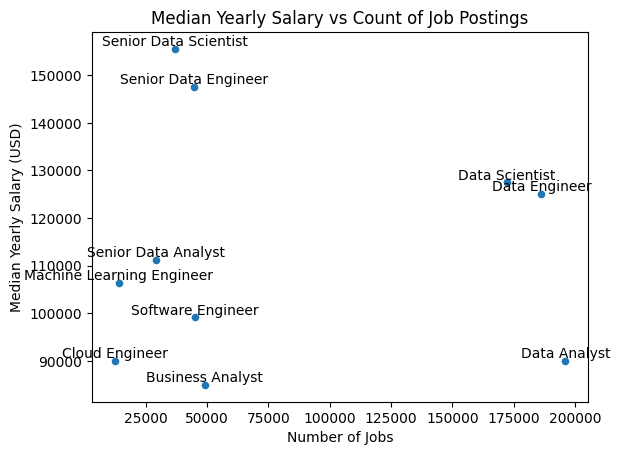

In [ ]:
job_stats = df.groupby('job_title_short').agg(
                median_salary=('salary_year_avg', 'median'),
                job_count=('job_title_short', 'size')
            ).dropna()

job_stats.plot(kind='scatter', y='median_salary' , x='job_count')
plt.xlabel('Number of Jobs')
plt.ylabel('Median Yearly Salary (USD)')
plt.title('Median Yearly Salary vs Count of Job Postings')

for i, txt in enumerate(job_stats.index):
    plt.text(job_stats['job_count'].iloc[i], job_stats['median_salary'].iloc[i], txt, ha='center', va='bottom')


Create a scatter plot to visualize the relationship between the number of job postings and median yearly salary for the top 7 countries based on highest number of job postings. Annotate each point with the country's name.

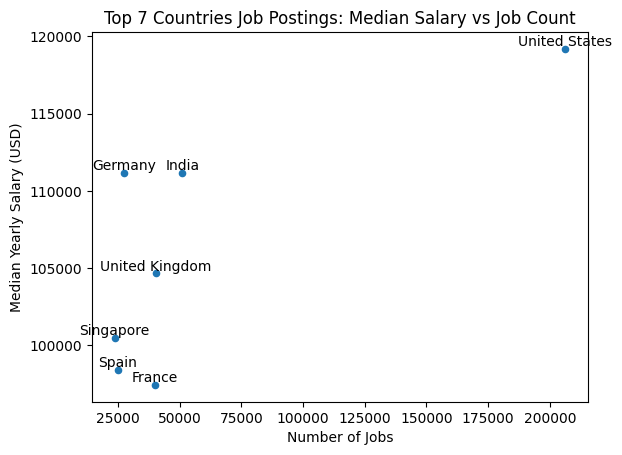

In [ ]:
job_stats = df.groupby('job_country').agg(
    job_count=('job_country', 'count'),
    median_yearly_salary=('salary_year_avg', 'median')
).dropna().sort_values(by='job_count', ascending=False).head(7)

job_stats.plot(kind='scatter', y='median_yearly_salary', x='job_count')
plt.ylabel('Median Yearly Salary (USD)')
plt.xlabel('Number of Jobs')
plt.title('Top 7 Countries Job Postings: Median Salary vs Job Count')

for i, txt in enumerate(job_stats.index):
    plt.text(job_stats['job_count'].iloc[i], job_stats['median_yearly_salary'].iloc[i], txt, ha='center', va='bottom')

Create a scatter plot to visualize the relationship between the average yearly salary and the job count filtering a DataFrame for:
    - Data Analyst, Data Scientist, and Data Engineer positions in job_title_short
    - United States for the job_country
    - 'Full-time' and 'Contractor' for the job_schedule_type
    -  Remove roles that do not have any yearly salary data.

Combine the job_title_short and job_schedule_type into one column (called job_title_type) in the newly created DataFrame to use as the labels for the plot.

For the plot use a for loop to cycle through the unique values in job_title_type and plot using the plt.scatter() function, specifying the label of job_title_type.

Ensure the legend is appearing.
Label the plot's axis and title appropriately.

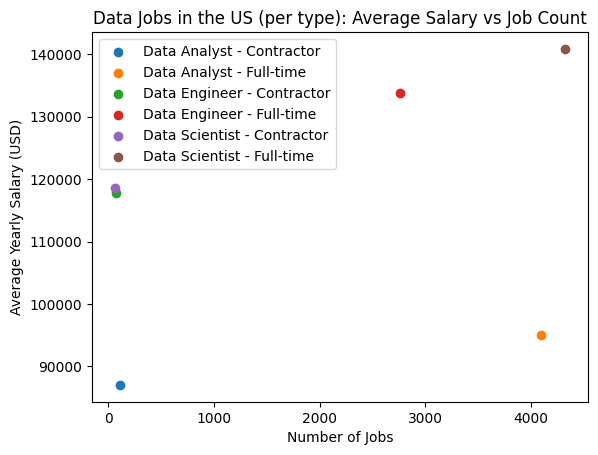

In [ ]:
target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

df_filtered = df[
   (df['job_country'] == 'United States') &
   (df['job_schedule_type'].isin(['Full-time', 'Contractor'])) &
   (df['job_title_short'].isin(target_job_titles))
].dropna(subset=['salary_year_avg']).copy()

df_filtered['job_title_type'] = df_filtered['job_title_short'] + ' - ' + df_filtered['job_schedule_type']

job_stats = df_filtered.groupby('job_title_type').agg(
    avg_salary=('salary_year_avg', 'mean'),
    job_count=('job_title_type', 'count')
).dropna()

job_stats.reset_index(inplace=True)

for _, row in job_stats.iterrows():
    plt.scatter(row['job_count'], row['avg_salary'], label=row['job_title_type'])

plt.xlabel('Number of Jobs')
plt.ylabel('Average Yearly Salary (USD)')
plt.title('Data Jobs in the US (per type): Average Salary vs Job Count')
plt.legend()


Create a line plot showing the trend of job postings over the months for Cloud Engineer job postings:

Create a new DataFrame called df_ce that filters only job postings that are 'Cloud Engineer'
Customize the plot by setting the line style to dotted, the line color to purple, and the marker style to 'o'.
Add a title 'Job Postings Trend for Cloud Engineers' and label the y-axis as 'Count of Job Postings'.

Text(0.5, 0, '')

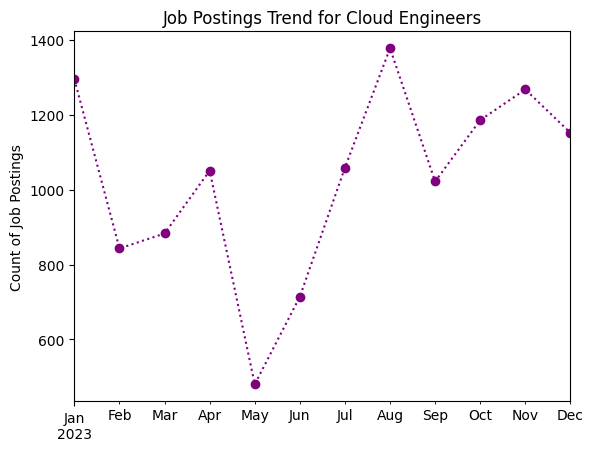

In [ ]:
df_ce = df[df['job_title_short'] == 'Cloud Engineer']
df_ce['Month'] = df_ce['job_posted_date'].dt.to_period('M') 
stats = df_ce.groupby('Month').size()
stats.plot(kind='line', linestyle=':', color='purple', marker='o')
plt.title('Job Postings Trend for Cloud Engineers')
plt.ylabel('Count of Job Postings')
plt.xlabel('')


Create a bar chart showing the top 5 job companies hiring for Senior Data Analyst roles:

Create a DataFrame called SDA_df. 
Customize the plot by setting the bar colors to 5 different colors with the variable colors.
Add a grid to the y-axis only and making it dashes.
Rotate the x-axis labels by 45 degrees.
Label the y-axis as 'Number of Job Postings' and set the title to 'Top 5 Companies hiring Senior Data Analysts by Number of Postings'; Make the font size 14.

Text(0.5, 0, '')

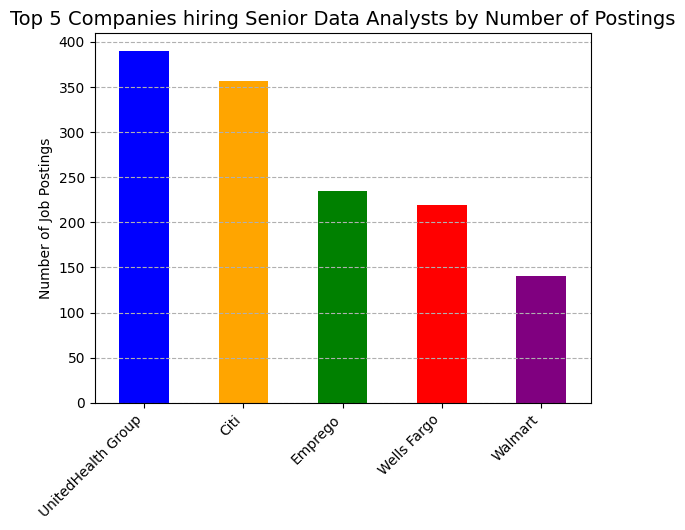

In [ ]:
colors = ['blue', 'orange', 'green', 'red', 'purple']

SDA_df = df[df['job_title_short'] == 'Senior Data Analyst']
company_jobs = SDA_df.groupby('company_name').size().sort_values(ascending=False).head()

company_jobs.plot(kind='bar', color=colors)
plt.grid(axis='y', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Job Postings')
plt.title('Top 5 Companies hiring Senior Data Analysts by Number of Postings', fontsize=14)
plt.xlabel('')

Create a histogram to show the distribution of hourly salaries (use salary_hour_avg column) for Data Scientist job postings:

Create a new DataFrame called df_DS to filter out 'Data Scientist' jobs.
Customize the plot by setting the number of bins to 40 and the bar color to blue.
Label the x-axis as 'Hourly Salary' and the y-axis as 'Number of Jobs'.

Text(0.5, 1.0, 'Distribution of Data Scientist Hourly Salaries')

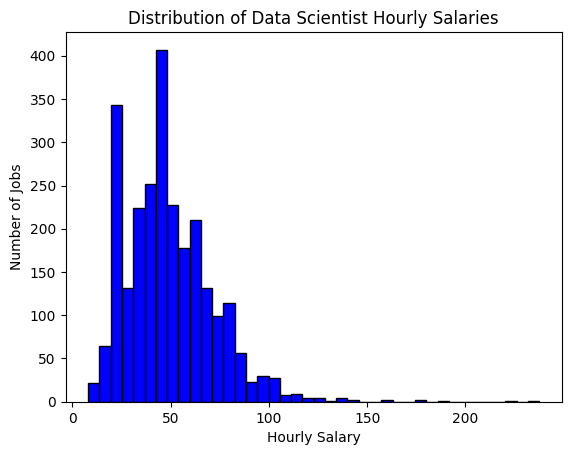

In [ ]:
df_DS = df[df['job_title_short'] == 'Data Scientist']
df_DS['salary_hour_avg'].plot(kind='hist', bins=40, color='blue', edgecolor='black')
plt.xlabel('Hourly Salary')
plt.ylabel('Number of Jobs')
plt.title('Distribution of Data Scientist Hourly Salaries')

Create a histogram to show the distribution of job postings by the number of skills listed using the job_skills column:

Create a new DataFrame called df_skills to filter out job postings with non-null job_skills.
Customize the plot by setting the number of bins to 55, the bar color to 'magenta'
Add a title 'Distribution of Job Postings by Number of Skills Listed'.
Label the x-axis as 'Number of Skills' and the y-axis as 'Number of Job Postings'.

<Axes: ylabel='Frequency'>

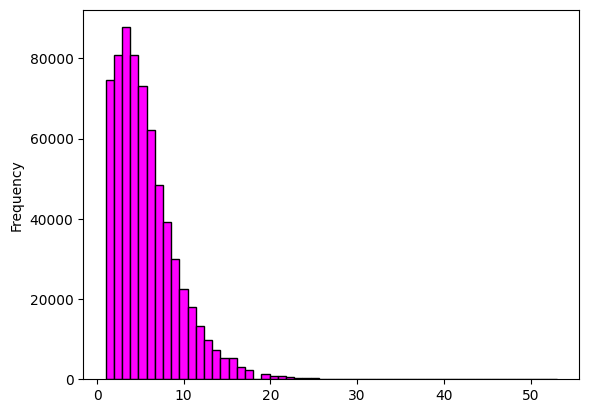

In [ ]:
df_skills = df.dropna(subset='job_skills').copy()
df_skills['num_skills'] = df_skills['job_skills'].apply(len)
df_skills['num_skills'].plot(kind='hist', bins=55, color='magenta', edgecolor='black')

Create a histogram to show the distribution of average yearly salaries (salary_year_avg) for Data Engineer job postings:

Create a new DataFrame called df_DE to filter out 'Data Engineer' jobs.
Customize the plot by setting the number of bins to 50, the bar color to red
Add annotations for the mean and median salaries, using plt.axvline(); for the parameters specify:
color: 'blue'/'green'
linestyle: 'dashed'
label: e.g., f'Mean: ${mean_salary:,.0f}'
Label the x-axis as 'Yearly Salary' and the y-axis as 'Number of Jobs'.

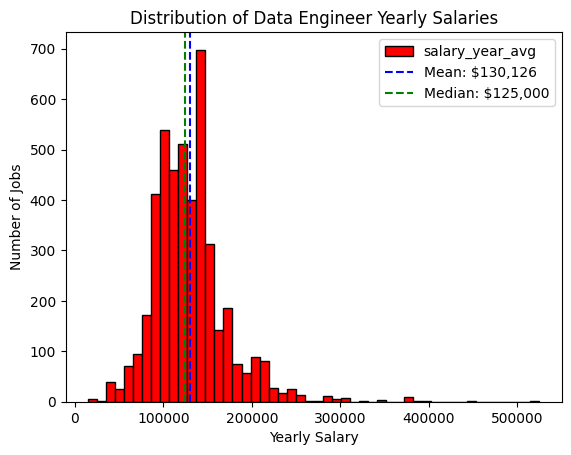

In [35]:
df_DE = df[df['job_title_short'] == 'Data Engineer'].copy()
df_DE = df_DE.dropna(subset=['salary_year_avg'])

# Get mean and median
mean_salary = df_DE['salary_year_avg'].mean()
median_salary = df_DE['salary_year_avg'].median()

# Plot the histogram
df_DE['salary_year_avg'].plot(kind='hist', bins=50, color='red', edgecolor='black')
plt.axvline(mean_salary, color='blue', linestyle='dashed', label=f'Mean: ${mean_salary:,.0f}')
plt.axvline(median_salary, color='green', linestyle='dashed', label=f'Median: ${median_salary:,.0f}')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.title('Distribution of Data Engineer Yearly Salaries')
plt.legend()
plt.show()

Create a box plot to visualize the distribution of salary_hour_avg for Data Scientist job postings in the United States. Label the x-axis as 'Data Scientist' and the y-axis as 'Hourly Salary ($USD)'.

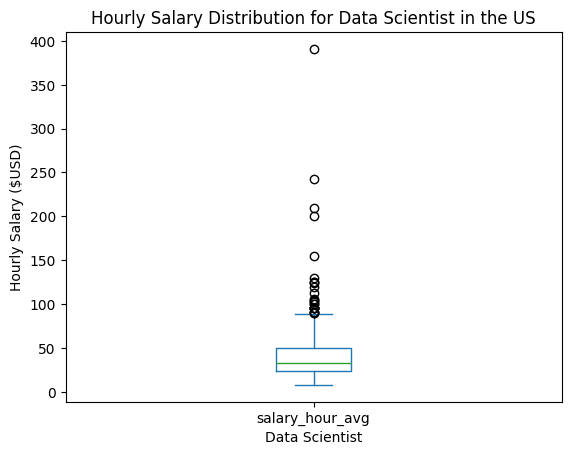

In [40]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].dropna(subset=['salary_hour_avg'])

df_DA_US['salary_hour_avg'].plot(kind='box')
plt.xlabel('Data Scientist')
plt.ylabel('Hourly Salary ($USD)')
plt.title('Hourly Salary Distribution for Data Scientist in the US')
plt.show()

Create a box plot to compare the distribution of salary_hour_avg for Data Analyst job postings in the United States and Canada.

Filter a DataFrame to include only 'Data Analyst' roles in these two countries.
Use list comprehension to create a list of DataFrames for each country.
Use the plt.boxplot() function to plot this list and specify the labels as countries.
Set the y-axis limit to 150 and the y-axis as 'Hourly Salary ($USD)'.

/var/folders/pg/gp3rsl0n3fs28cvzwhklj82m0000gn/T/ipykernel_35330/3349083576.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(country_data, labels=countries)


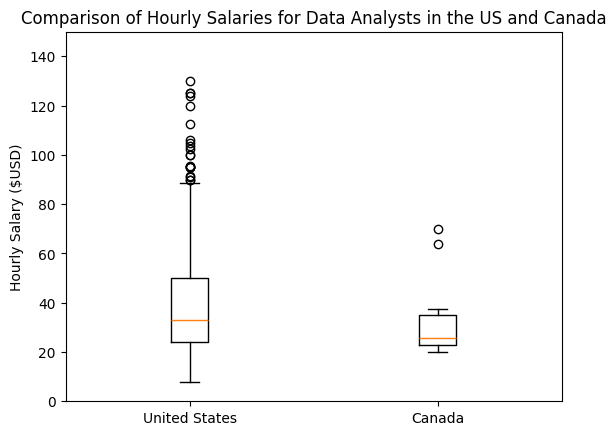

In [48]:
countries = ['United States', 'Canada']
df_filtered = df[(df['job_country'].isin(countries)) & (df['job_title_short'] == 'Data Analyst')].dropna(subset='salary_hour_avg')

country_data = [df_filtered[df_filtered['job_country'] == country]['salary_hour_avg'] for country in countries]

plt.boxplot(country_data, labels=countries)
plt.ylim(0,150)
plt.xlabel('')
plt.ylabel('Hourly Salary ($USD)')
plt.title('Comparison of Hourly Salaries for Data Analysts in the US and Canada')
plt.show()

Create a box plot to compare the distribution of salary_hour_avg for Data Analyst, Data Engineer, and Data Scientist job postings in Canada.
Label the x-axis as 'Job Title' and format the y-axis to have '$' before the number then label it as 'Hourly Salary (USD)'.

/var/folders/pg/gp3rsl0n3fs28cvzwhklj82m0000gn/T/ipykernel_35330/4019783457.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(canada_data, labels=jobs)


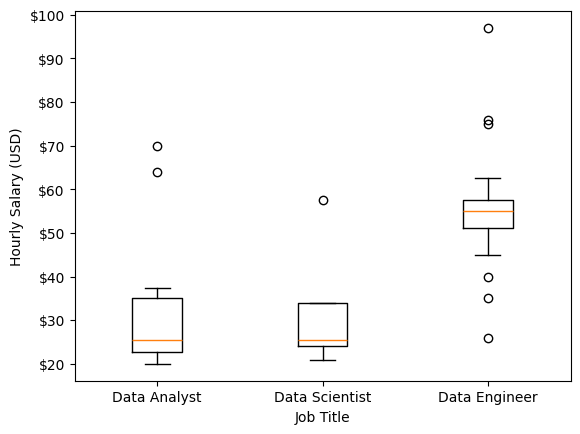

In [60]:
jobs = ['Data Analyst', 'Data Scientist', 'Data Engineer']

df_filtered = df[(df['job_title_short'].isin(jobs)) & (df['job_country'] == 'Canada')].dropna(subset='salary_hour_avg')

canada_data = [df_filtered[df_filtered['job_title_short'] == job]['salary_hour_avg'] for job in jobs]

fig, ax = plt.subplots()
ax.boxplot(canada_data, labels=jobs)
ax.set_xlabel('Job Title')
ax.set_ylabel('Hourly Salary (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y)}'))
plt.show()


In [ ]:
Create a Seaborn bar plot to visualize the top 5 companies with the highest median salary_year_avg 
for Data Scientist job postings in the United States.

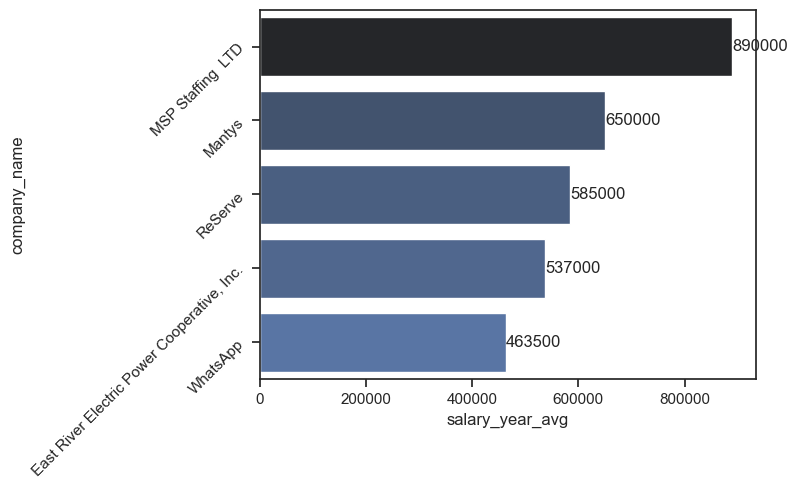

In [93]:
import seaborn as sns 

top_companies = df.groupby('company_name')['salary_year_avg'].median().sort_values(ascending=False).reset_index().head()

sns.set_theme(style='ticks')
ax = sns.barplot(top_companies, y='company_name', x='salary_year_avg', hue='salary_year_avg', palette='dark:b_r')

for container in ax.containers:
    ax.bar_label(container)

plt.yticks(rotation=45, ha='right')
plt.legend().remove()
plt.show()


Create a histogram using Seaborn to visualize the distribution of average yearly salaries (use the salary_year_avg column) for Data Scientist job postings in the United States:

Filter the DataFrame to include only job postings in the United States and remove any entries with missing yearly salary values.
Use 25 bins for the histogram and set the x-axis limit to 700,000.
Set the title to 'Distribution of Yearly Salaries for Data Scientist in the United States' and label the y-axis 'Number of Jobs' and x-axis 'Yearly Salary (USD)'.

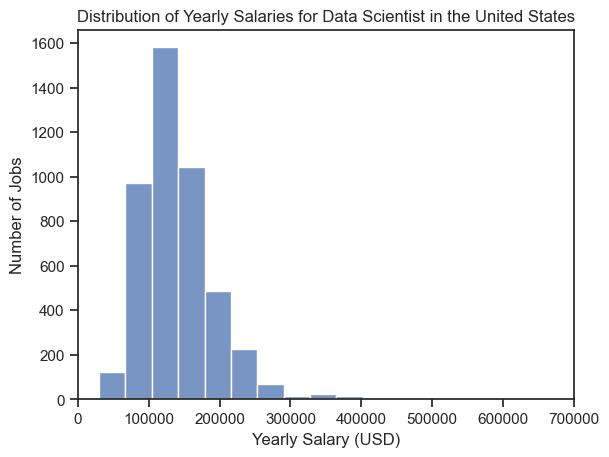

In [92]:
df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].copy()
df_DS_US = df_DS_US.dropna(subset='salary_year_avg')

sns.histplot(df_DS_US['salary_year_avg'], bins=25, kde=False)
plt.xlim(0,700000)
plt.title('Distribution of Yearly Salaries for Data Scientist in the United States')
plt.ylabel('Number of Jobs')
plt.xlabel('Yearly Salary (USD)')
plt.show()


Create a box plot using Seaborn to compare the yearly salaries (use the salary_year_avg column) of Data Analyst, Data Engineer, and Data Scientist job postings in India:

Filter the DataFrame to include only job postings in India and remove any entries with missing yearly salary values.
Set the x-axis limit to 300,000 and format it as $100k.
Set the title to 'Yearly Salary Comparison for Data Roles in India' and label the x-axis as 'Yearly Salary (USD)'.

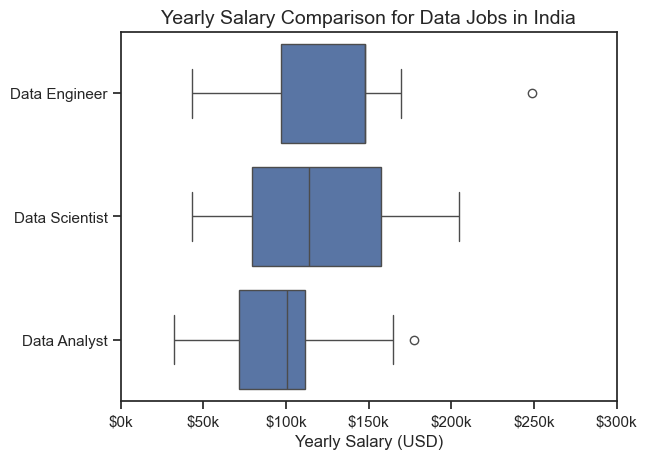

In [121]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_filtered = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'India')].copy()
df_filtered = df_filtered.dropna(subset='salary_year_avg')

sns.boxplot(data=df_filtered, x='salary_year_avg', y='job_title_short')
plt.xlim(0,300000)
plt.ylabel('')
plt.xlabel('Yearly Salary (USD)')
plt.title('Yearly Salary Comparison for Data Jobs in India', fontsize=14)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.show()


Create a violin plot using Seaborn to visualize the distribution of salary_year_avg for Data Scientist roles in the United States.
Ensure the plot includes a title, axis labels, and custom formatting for the salary axis.

Text(0.5, 1.0, 'Distribution of Yearly Salary for Data Scientist in the US')

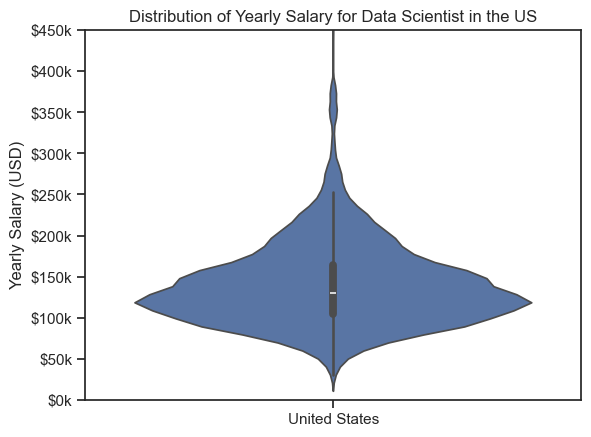

In [137]:
sns.violinplot(data=df_DS_US, x='job_country', y='salary_year_avg')

plt.xlabel('')
plt.ylabel('Yearly Salary (USD)')
plt.ylim(0,450000)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))
plt.title('Distribution of Yearly Salary for Data Scientist in the US')